<a href="https://colab.research.google.com/github/divyasri-jonnadula-16/spoken-language-identification/blob/main/ResNet18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch torchaudio torchvision scikit-learn matplotlib seaborn

In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [ ]:
class LanguageDataset(Dataset):
    def __init__(self, root_dir, sample_rate=16000, duration=3):
        self.root_dir = root_dir
        self.sample_rate = sample_rate
        self.max_length = sample_rate * duration

        self.file_paths = []
        self.labels = []

        self.label_map = {"english":0, "german":1, "spanish":2}

        for lang in os.listdir(root_dir):
            lang_path = os.path.join(root_dir, lang)
            if os.path.isdir(lang_path):
                for file in os.listdir(lang_path):
                    if file.endswith(".flac"):
                        self.file_paths.append(os.path.join(lang_path, file))
                        self.labels.append(self.label_map[lang])

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        path = self.file_paths[idx]
        label = self.labels[idx]

        waveform, sr = torchaudio.load(path)

        if sr != self.sample_rate:
            resampler = torchaudio.transforms.Resample(sr, self.sample_rate)
            waveform = resampler(waveform)

        if waveform.size(1) > self.max_length:
            waveform = waveform[:, :self.max_length]
        else:
            pad = self.max_length - waveform.size(1)
            waveform = F.pad(waveform, (0, pad))

        return waveform, torch.tensor(label)

In [ ]:
train_dataset = LanguageDataset("/content/drive/MyDrive/spokenvoice/train")
test_dataset = LanguageDataset("/content/drive/MyDrive/spokenvoice/test")

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [ ]:
mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=16000,
    n_mels=128
).to(device)

db_transform = torchaudio.transforms.AmplitudeToDB().to(device)

/usr/local/lib/python3.12/dist-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(


In [ ]:
model = models.resnet18(pretrained=True)

# Modify first layer for 1 channel input
model.conv1 = nn.Conv2d(
    1, 64, kernel_size=7, stride=2, padding=3, bias=False
)

# Modify final layer for 3 languages
model.fc = nn.Linear(model.fc.in_features, 3)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 140MB/s]


In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

In [ ]:
from torch.utils.data import random_split

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [ ]:
EPOCHS = 30
patience = 5
best_val_loss = float("inf")
counter = 0

for epoch in range(EPOCHS):

    # -------- TRAIN --------
    model.train()
    train_loss = 0

    for audio, labels in train_loader:
        audio = audio.to(device)
        labels = labels.to(device)

        mel = mel_transform(audio)
        mel = db_transform(mel)

        mel = mel.squeeze(1)
        mel = mel.unsqueeze(1)

        outputs = model(mel)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # -------- VALIDATION --------
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for audio, labels in val_loader:
            audio = audio.to(device)
            labels = labels.to(device)

            mel = mel_transform(audio)
            mel = db_transform(mel)

            mel = mel.squeeze(1)
            mel = mel.unsqueeze(1)

            outputs = model(mel)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    # -------- EARLY STOPPING --------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_model.pth")
        print("Validation improved. Model saved.")
    else:
        counter += 1
        print(f"No improvement ({counter}/{patience})")

        if counter >= patience:
            print("Early stopping triggered!")
            break

Epoch 1 | Train Loss: 0.0322 | Val Loss: 0.0158
Validation improved. Model saved.
Epoch 2 | Train Loss: 0.0115 | Val Loss: 0.0005
Validation improved. Model saved.
Epoch 3 | Train Loss: 0.0039 | Val Loss: 0.0002
Validation improved. Model saved.
Epoch 4 | Train Loss: 0.0061 | Val Loss: 0.0016
No improvement (1/5)
Epoch 5 | Train Loss: 0.0061 | Val Loss: 0.0003
No improvement (2/5)
Epoch 6 | Train Loss: 0.0072 | Val Loss: 0.0276
No improvement (3/5)
Epoch 7 | Train Loss: 0.0203 | Val Loss: 0.0470
No improvement (4/5)
Epoch 8 | Train Loss: 0.0183 | Val Loss: 0.0201
No improvement (5/5)
Early stopping triggered!


In [ ]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for audio, labels in test_loader:
        audio = audio.to(device)
        labels = labels.to(device)

        mel = mel_transform(audio)
        mel = db_transform(mel)
        # Removed: mel = mel.unsqueeze(1) as it creates an extra dimension

        outputs = model(mel)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [ ]:
print("Classification Report:\n")
print(classification_report(
    all_labels,
    all_preds,
    target_names=["English","German","Spanish"]
))

Classification Report:

              precision    recall  f1-score   support

     English       0.54      0.87      0.67       180
      German       0.31      0.11      0.16       180
     Spanish       0.68      0.71      0.70       180

    accuracy                           0.56       540
   macro avg       0.51      0.56      0.51       540
weighted avg       0.51      0.56      0.51       540



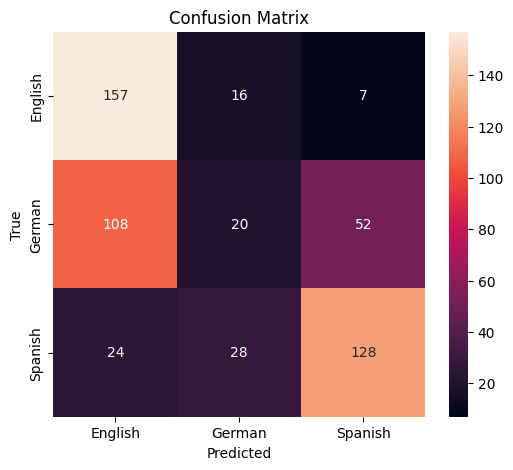

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["English","German","Spanish"],
            yticklabels=["English","German","Spanish"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()